In [1]:
import numpy as np
import matplotlib.pyplot as plt
from data_loader import data


X = data.T
X_centered = X - X.mean(axis=0)
print(f"Форма матриці даних: {X_centered.shape}", "\n")

C:\Users\marty\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting EDF parameters from C:\Users\marty\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Форма матриці даних: (64, 9760)
[ 2.20228566e-20 -3.82574840e-05 -4.22196813e-05 -3.02570161e-05
 -2.78584974e-05 -2.40448936e-05 

In [2]:
covariance_matrix = X_centered.T @ X_centered / (X.shape[0] - 1)
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

eig_median = np.median(eigenvalues)
critical_threshold = eig_median * 10#10 just because, not much thought behind. may change upon request
eigenvalues_mask = eigenvalues[eigenvalues <= critical_threshold]


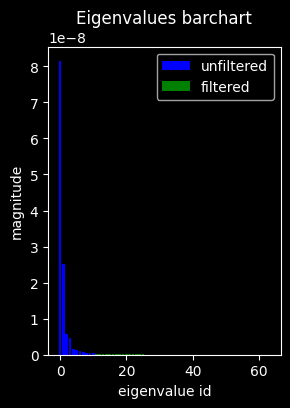

In [3]:
#barring (-_-) the eigenvalues
fig = plt.figure(figsize=(3, 4))
ax = fig.add_subplot(111)
ax.bar(range(len(eigenvalues)), eigenvalues[::-1], align='center', color='b', label="unfiltered")
ax.bar(range(len(eigenvalues) - len(eigenvalues_mask), len(eigenvalues)), eigenvalues_mask[::-1], color='g', label="filtered" )
ax.set_xlabel("eigenvalue id")
ax.set_ylabel("magnitude")
plt.legend()
plt.title("Eigenvalues barchart")
plt.show()

In [4]:
#PCA. change of base and projection
data_eig_base = X_centered @ eigenvectors
data_eig_base[: len(eigenvalues_mask):] = 0 #project onto non-principal hyperplane
X_cleaned = data_eig_base @ eigenvectors.T

print(X_cleaned.shape) #to check for potential errors

(9760, 64)


In [5]:
#FFT. Frequency decomposition
from data_loader import raw
channel_names = raw.info['ch_names'] #electrode code-names
fs = raw.info['sfreq'] #sampling frequency - [Hz] (aka data entry speed)
# print(channel_names)
target = 'O1' #resting state channel
target_id = channel_names.index(target)
target_data = X_cleaned[:, target_id]

N = len(target_data) #num of time samples
fft_values = np.fft.rfft(target_data)
fft_frequencies = np.fft.rfftfreq(N, 1/fs)
fft_power = np.abs(fft_values) ** 2





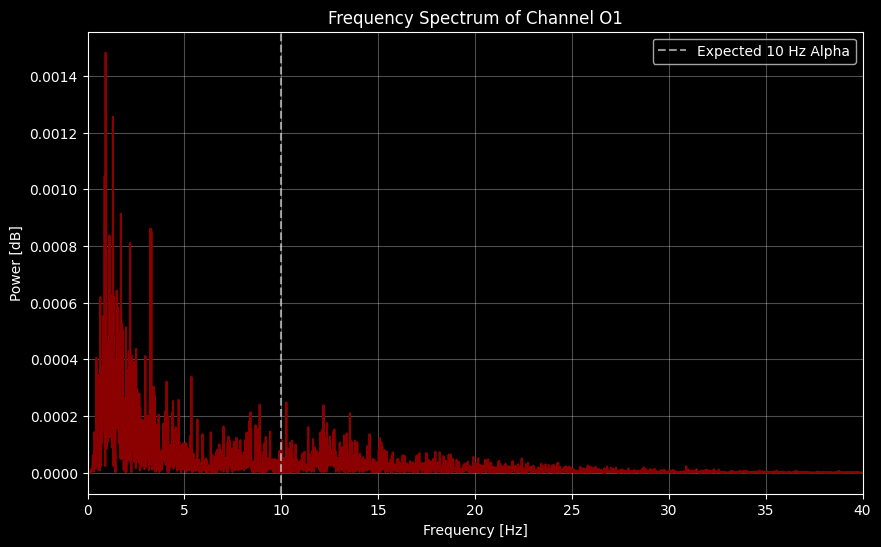

In [6]:
#Plotting the FFT
plt.figure(figsize=(10, 6))
plt.plot(fft_frequencies, fft_power, color='darkred')

plt.xlim(0, 40)
plt.axvline(x=10, color='lightgray', linestyle='--', alpha=0.7, label='Expected 10 Hz Alpha')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [dB]")
plt.title('Frequency Spectrum of Channel O1')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()